<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/Copia_de_Libreta_Fraude_de_tarjetas_Redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Anáhuac Puebla
## Dr. Farid Krayem Pineda

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data set:
https://www.kaggle.com/datasets/whenamancodes/fraud-detection

In [2]:
import os

# Install Kaggle API client
!pip install kaggle

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move kaggle.json to the correct directory
# This assumes you've uploaded kaggle.json to /content/
if os.path.exists('/content/kaggle.json'):
    !mv /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print('Kaggle API key configured successfully.')
else:
    print('WARNING: kaggle.json not found in /content/. Please upload it to /content/ and run this cell again.')
    print('Instructions: Go to Kaggle (kaggle.com/your-username/account), click "Create New API Token" to download kaggle.json, then upload it to Colab via the file browser (folder icon on left -> upload icon).')


Instructions: Go to Kaggle (kaggle.com/your-username/account), click "Create New API Token" to download kaggle.json, then upload it to Colab via the file browser (folder icon on left -> upload icon).


In [3]:
# Download the dataset
# The dataset slug is 'whenamancodes/fraud-detection'
!kaggle datasets download -d whenamancodes/fraud-detection

print('Dataset downloaded.')

Dataset URL: https://www.kaggle.com/datasets/whenamancodes/fraud-detection
License(s): ODbL-1.0
100% 66.0M/66.0M [00:00<00:00, 71.3MB/s]

Dataset downloaded.


In [4]:
# Unzip the dataset
import zipfile
import pandas as pd

# Find the downloaded zip file (it's usually named after the dataset slug, or a generic 'fraud-detection.zip')
# We'll assume the zip file is in the current directory, which is /content/ in Colab
zip_file_name = 'fraud-detection.zip' # Or check for 'creditcardfraud.zip'
if not os.path.exists(zip_file_name):
    # Fallback to the name often used inside the zip
    zip_file_name = 'creditcardfraud.zip'

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f'Successfully unzipped {zip_file_name}.')

    # Load the CSV file into a pandas DataFrame
    # The extracted CSV file is usually named 'creditcard.csv'
    csv_file_name = 'creditcard.csv'
    if os.path.exists(csv_file_name):
        datos_fraude_df = pd.read_csv(csv_file_name)
        print(f'Successfully loaded {csv_file_name} into datos_fraude_df.')
        print('First 5 rows of datos_fraude_df:')
        display(datos_fraude_df.head())
    else:
        print(f'ERROR: {csv_file_name} not found after unzipping.')
else:
    print(f'ERROR: Neither fraud-detection.zip nor creditcardfraud.zip found.')


Successfully unzipped fraud-detection.zip.
Successfully loaded creditcard.csv into datos_fraude_df.
First 5 rows of datos_fraude_df:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
import pandas as pd

# Adjust the path to your CSV file as needed
# datos_fraude_df = pd.read_csv('/content/drive/MyDrive/Anáhuac - Mineria de Datos/Libretas/data/fraude_creditcard.csv')

# The dataset has already been loaded from Kaggle into datos_fraude_df by the previous steps.
# If you intend to use the drive file, uncomment the line above and comment out the Kaggle download/unzip steps.

print('Successfully loaded the CSV file into datos_fraude_df.')

Successfully loaded the CSV file into datos_fraude_df.


In [5]:
print('First 5 rows of datos_fraude_df:')
display(datos_fraude_df.head())

First 5 rows of datos_fraude_df:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Create fraude_df containing only fraudulent transactions
fraude_df = datos_fraude_df[datos_fraude_df['Class'] == 1]

print('First 5 rows of fraude_df (fraudulent transactions):')
display(fraude_df.head())

First 5 rows of fraude_df (fraudulent transactions):


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [7]:
datos_fraude_df.shape

(284807, 31)

In [ ]:
fraude_df.shape

(492, 31)

In [9]:
# Create no_fraude_df by randomly sampling 492 non-fraudulent transactions
no_fraude_df = datos_fraude_df[datos_fraude_df['Class'] == 0].sample(n=492, random_state=42)

print('First 5 rows of no_fraude_df (non-fraudulent transactions):')
display(no_fraude_df.head())

First 5 rows of no_fraude_df (non-fraudulent transactions):


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
138028,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
63099,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
73411,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
164247,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
148999,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0


In [10]:
no_fraude_df.shape

(492, 31)

In [11]:
# Reset the index for fraude_df and drop the old index
fraude_df = fraude_df.reset_index(drop=True)

print('First 5 rows of fraude_df after index reset:')
display(fraude_df.head())

First 5 rows of fraude_df after index reset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
1,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
2,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
3,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
4,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [12]:
# Reset the index for no_fraude_df and drop the old index
no_fraude_df = no_fraude_df.reset_index(drop=True)

print('First 5 rows of no_fraude_df after index reset:')
display(no_fraude_df.head())

First 5 rows of no_fraude_df after index reset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
1,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
2,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
3,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
4,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0


In [13]:
# Concatenate fraude_df and no_fraude_df to create combined_df
combined_df = pd.concat([fraude_df, no_fraude_df], ignore_index=True)

print('First 5 rows of combined_df:')
display(combined_df.head())

First 5 rows of combined_df:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
1,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
2,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
3,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
4,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [14]:
print('Last 5 rows of combined_df:')
display(combined_df.tail())

Last 5 rows of combined_df:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
979,76376.0,-1.525978,0.796226,1.172478,-0.947111,0.077071,-1.655590,0.670737,0.051626,-0.887067,...,0.057467,-0.072446,-0.397195,0.825601,0.404932,0.923867,-0.262266,-0.133368,23.00,0
980,60348.0,-0.705795,1.418016,0.993756,0.908646,-0.171163,-0.566892,0.367416,0.421875,-0.736533,...,0.197948,0.655792,-0.048655,0.415045,-0.287710,-0.305466,0.311077,0.161942,2.80,0
981,47151.0,0.995185,-0.147746,-0.108914,1.168451,0.329676,1.182090,-0.316034,0.323043,0.541030,...,-0.050798,0.005680,-0.370879,-1.385989,0.746056,-0.191335,0.070408,0.041460,98.90,0
982,53857.0,-1.197741,3.166857,-3.476764,0.818768,1.310580,-0.445066,0.384113,0.497864,0.552898,...,-0.293749,-0.264981,0.090417,-1.691177,0.032926,-0.285576,0.752378,0.345595,0.89,0
983,65405.0,-0.558983,-0.431438,1.893696,-1.783053,-1.752650,0.522665,1.156169,-0.430282,1.762763,...,0.119397,0.968116,-0.352839,0.049816,0.329348,-0.412496,-0.153488,-0.443773,281.34,0


In [15]:
print('Shape of combined_df:')
print(combined_df.shape)

Shape of combined_df:
(984, 31)


In [16]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

### Prepare the Data for the Neural Network

First, we need to separate our features (X) from our target variable (y). The 'Class' column is our target variable, indicating fraud (1) or no fraud (0).

In [17]:
# Separate features (X) and target (y)
X = combined_df.drop('Class', axis=1)
y = combined_df['Class']

print(f'Shape of X (features): {X.shape}')
print(f'Shape of y (target): {y.shape}')

Shape of X (features): (984, 30)
Shape of y (target): (984,)


In [18]:
print(y)

0      1
1      1
2      1
3      1
4      1
      ..
979    0
980    0
981    0
982    0
983    0
Name: Class, Length: 984, dtype: int64


Next, we'll split the data into training and testing sets. This is crucial for evaluating our model's performance on unseen data. A common split is 70% for training and 30% for testing.

In [19]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (688, 30)
Shape of X_test: (296, 30)
Shape of y_train: (688,)
Shape of y_test: (296,)


Finally, we'll scale the numerical features. Neural networks often perform better when input features are scaled to a similar range. `StandardScaler` will transform the data to have a mean of 0 and a standard deviation of 1.

In [20]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled successfully.')

Features scaled successfully.


### Build and Train the Neural Network Model

We will create a simple sequential neural network. This model will have:

*   An input layer matching the number of features in our dataset.
*   One or more hidden layers with `ReLU` activation functions.
*   An output layer with a `sigmoid` activation function for binary classification (fraud or not fraud).

The model will be compiled with the `Adam` optimizer and `binary_crossentropy` loss, suitable for binary classification tasks.

In [21]:
# Define the neural network model
model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],)), # Input layer
    tf.keras.layers.Dense(64, activation='relu'), # Hidden layer 1
    tf.keras.layers.Dropout(0.3), # Dropout for regularization
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer 2
    tf.keras.layers.Dropout(0.3), # Dropout for regularization
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
print('Neural Network Model Summary:')
model.summary()

Neural Network Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

Now, let's train the model using our scaled training data. We'll specify the number of epochs and a batch size. Validation data (`(X_test_scaled, y_test)`) is provided to monitor performance on unseen data during training.

In [22]:
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=1)

print('\nModel training complete.')

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6715 - loss: 0.5819 - val_accuracy: 0.8716 - val_loss: 0.4645
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8459 - loss: 0.4330 - val_accuracy: 0.8919 - val_loss: 0.3625
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8823 - loss: 0.3577 - val_accuracy: 0.8986 - val_loss: 0.3025
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9026 - loss: 0.2916 - val_accuracy: 0.9122 - val_loss: 0.2657
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9012 - loss: 0.2857 - val_accuracy: 0.9122 - val_loss: 0.2406
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9041 - loss: 0.2520 - val_accuracy: 0.9155 - val_loss: 0.2202
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9084 - loss: 0.2416 - val_accuracy: 0.9291 - val_loss: 0.2125
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9172 - loss: 0.2290 - val_accuracy: 0.9392 - v

### Evaluate the Model

After training, it's essential to evaluate the model's performance on the test set. We'll predict the 'Class' for `X_test_scaled` and then compare these predictions against the actual `y_test` values using various metrics.

In [23]:
# Make predictions on the test set
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

print('Model predictions complete.')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Model predictions complete.


#### Performance Metrics

Given the imbalanced nature of the original dataset (even though we balanced our training set), metrics beyond simple accuracy are important. We will look at:

*   **Confusion Matrix**: To understand true positives, true negatives, false positives, and false negatives.
*   **Classification Report**: Provides precision, recall, and F1-score for each class.
*   **Accuracy Score**: Overall correctness.
*   **Precision**: Of all samples predicted as positive, how many were actually positive.
*   **Recall (Sensitivity)**: Of all actual positive samples, how many were correctly predicted as positive.
*   **F1-Score**: Harmonic mean of precision and recall.

In [24]:
# Evaluate the model
print('\n--- Model Evaluation ---')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print(f'\nAccuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')


--- Model Evaluation ---
Confusion Matrix:
[[140   8]
 [ 10 138]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       148
           1       0.95      0.93      0.94       148

    accuracy                           0.94       296
   macro avg       0.94      0.94      0.94       296
weighted avg       0.94      0.94      0.94       296


Accuracy: 0.9392
Precision: 0.9452
Recall: 0.9324
F1-Score: 0.9388


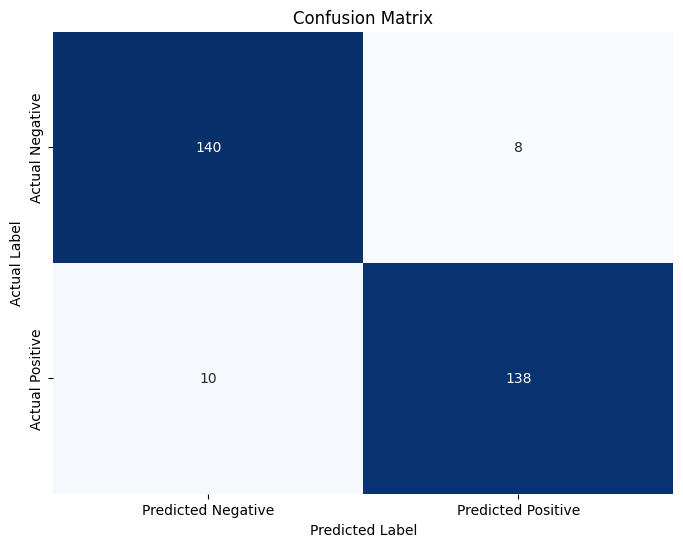

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()